Today's topics:
* correlation and the Pearson `r`
* the direction and strength of a correlation
* spurious correlations

# Correlated material properties

Consider the destructive tensile testing of Ti alloys.
We can obtain two different stresses from each tensile test.
Yield strength (YS) is the stress where it starts to deform permanently.
Ultimate tensile strength (UTS) is the highest stress it reaches during the test.

<img src="https://upload.wikimedia.org/wikipedia/commons/6/6f/Al_tensile_test.jpg" alt="An aluminum alloy tensile specimen broken in two, with visible necking near the break and a cup and cone fracture surface" width=520/>

*Photo by Sigmund, [CC BY-SA 3.0](https://creativecommons.org/licenses/by-sa/3.0/), [via Wikimedia Commons](https://commons.wikimedia.org/wiki/File:Al_tensile_test.jpg).*

Above: A tensile specimen taken to fracture.
The "necking" near the break is permanent deformation.

The two schematic curves above show the relation between YS and UTS.
An alloy with higher YS *typically* also reaches higher UTS.
Is it always true?

# The titanium alloy dataset

We used this titanium alloy dataset before: [Salvador et al., *Scientific Data* 9, 188](https://doi.org/10.1038/s41597-022-01283-9) (CC BY 4.0.)

In [1]:
import pandas as pd

url = 'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/biomaterials_ti_alloys.csv'
data = pd.read_csv(url)
display(data)

,eid,Al_frac,Cr_frac,Cu_frac,Fe_frac,Hf_frac,Mn_frac,Mo_frac,Nb_frac,Ni_frac,...,DAR_pct,DAR_err,test_mode,HV,HV_err,Mo_equivalent,Mo_equivalent_class,ref_doi,ref_key,comments
0,Ti-23Nb-10Zr-2.0Fe,0.0,0.0,0.0,0.023400,0.0,0.0,0.0,0.135800,0.0,...,10.0,1.0,tension,252.0,8.0,12.88,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
1,Ti-27Nb-10Zr-1.5Fe,0.0,0.0,0.0,0.015600,0.0,0.0,0.0,0.163200,0.0,...,9.0,1.0,tension,229.0,2.0,11.65,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
2,Ti-31Nb-10Zr-1.0Fe,0.0,0.0,0.0,0.013801,0.0,0.0,0.0,0.189919,0.0,...,15.0,6.0,tension,218.0,5.0,12.08,meta,10.1007/s10853-021-06002-0,salvador2021,Young modulus obtained via tensile tests (Tabl...
3,Ti-11Nb-7Zr-3.5Fe,0.0,0.0,0.0,0.034903,0.0,0.0,0.0,0.061806,0.0,...,4.0,1.0,tension,358.0,3.0,13.78,meta,10.1016/j.matdes.2018.10.040,dalbo2018,Young modulus obtained via tensile tests (Tabl...
4,Ti-19Nb-6Sn-2.5Fe,0.0,0.0,0.0,0.025600,0.0,0.0,0.0,0.110000,0.0,...,31.0,5.0,tension,260.0,9.0,12.76,meta,10.1016/j.matdes.2018.10.040,dalbo2018,Young modulus obtained via tensile tests (Tabl...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
278,at_Ti-20Fe-3Sn,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,0.000000,0.0,...,-3.5,NaN,compression,513.0,NaN,62.79,stable,10.1016/j.jallcom.2019.01.346,li2019,Compression tests in cylindrical samples with ...
279,at_Ti-20Fe-5Sn,0.0,0.0,0.0,0.200000,0.0,0.0,0.0,0.000000,0.0,...,-10.4,NaN,compression,558.0,NaN,61.11,stable,10.1016/j.jallcom.2019.01.346,li2019,Compression tests in cylindrical samples with ...
280,at_Ti-10Fe-3Sn-3Nb,0.0,0.0,0.0,0.100000,0.0,0.0,0.0,0.030000,0.0,...,-50.0,NaN,compression,NaN,NaN,32.56,stable,10.1016/j.msea.2017.08.060,zhao2017,Alpha-dp presence disputable. Reported elongat...
281,at_Ti-12Fe-3Sn-3Nb,0.0,0.0,0.0,0.120000,0.0,0.0,0.0,0.030000,0.0,...,-50.0,NaN,compression,NaN,NaN,38.65,stable,10.1016/j.msea.2017.08.060,zhao2017,Additional phases were not characterized. Repo...


# Correlations

## Visual assessment

Let's make a scatter plot of our UTS versus YS.

Text(0, 0.5, 'Ultimate Tensile Strength (MPa)')

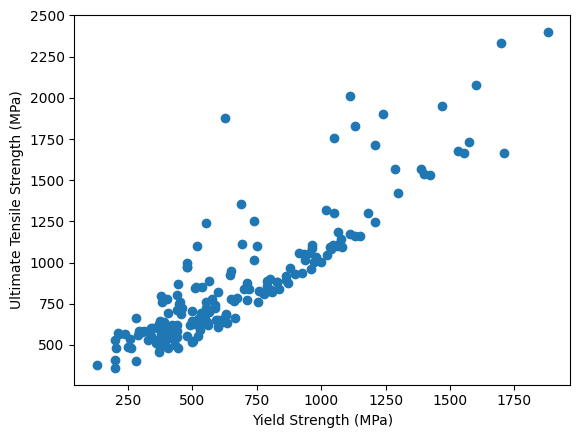

In [2]:
import matplotlib.pyplot as plt

x = data['YS_MPa']
y = data['UTS_MPa']

fig, ax = plt.subplots()
ax.scatter(x, y)
ax.set_xlabel('Yield Strength (MPa)')
ax.set_ylabel('Ultimate Tensile Strength (MPa)')
# no legend needed - just one series

The cloud has an upward slope, so alloys with a high yield strength tend to have a high tensile strength.
The points sit in a band rather than on a line - that's expected so many different materials and studies.
Not always: alloys with similar yield strengths can differ widely in tensile strength.
(e.g., around 700 MPa YS).

"Upward slope" is a qualitative description. Let's see if we can make it quantitative.

The **Pearson correlation coefficient**, with symbol $r$, tells us how close a cloud of points comes to a 1D line.

We'll use a new package, `SciPy`, and compute it with `scipy.stats.pearsonr`.

It returns two numbers, so we assign them to two names separated by a comma, the way `fig, ax = plt.subplots()` does.

`r` is the correlation coefficient, and `p` is a p-value (we won't use that today).

Try it on `YS_MPa` and `UTS_MPa`:

In [3]:
from scipy import stats

r, p = stats.pearsonr(x, y)
print(f"r = {r:.3f}")

r = nan


The result is `nan` ... ?

We saw this in L08: `np.mean` returned `nan` when an array contained a missing value.

We used `np.nanmean` to average only the recorded values.

A correlation uses yield strength and tensile strength from the same alloy **as a pair.**

Skipping missing entries in each column separately could pair measurements from different alloys.
`stats.pearsonr` does not skip incomplete pairs, so we first filter to only rows with both measurements.

## Rows with both measurements: `.dropna`

Pandas has a way to solve this problem, using `.dropna`.
This stands for "drop NaN". 
However, there will be a problem:

In [4]:
display(data.dropna())

# To keep more values, we'll need to use the `subset=` keyword argument.
#
# In `.dropna(subset=['YS_MPa', 'UTS_MPa'])`, `subset` names the two columns we need, as a list.
#
# `.dropna` keeps a row if both measurements are present, even when another property is missing.

,eid,Al_frac,Cr_frac,Cu_frac,Fe_frac,Hf_frac,Mn_frac,Mo_frac,Nb_frac,Ni_frac,...,DAR_pct,DAR_err,test_mode,HV,HV_err,Mo_equivalent,Mo_equivalent_class,ref_doi,ref_key,comments


In [5]:
both = data.dropna(subset=['YS_MPa', 'UTS_MPa'])
print(f'{len(both)} of {len(data)} alloys report both properties')

x = both['YS_MPa']   # uses the NEW dataframe
y = both['UTS_MPa']  # SAME as x

190 of 283 alloys report both properties


Of the 283 alloys, 190 have both measurements, so the correlation describes those 190.

The scatter above also used only these 190 complete pairs because `ax.scatter` skips rows with a missing value in either plotted column.
(where would it draw the point if one of x or y is `NaN`?)

## Building `r` from deviations

What does `stats.pearsonr` compute?
We can calculate that number ourselves.

In L05 we subtracted the mean from a column to get its *deviations*.
Then we squared them and summed the squares to get the *variance*.

Here we have two columns, so we take the deviations of both.

In [6]:
import numpy as np

dx = x - np.mean(x)  # each alloy's YS, relative to the mean
dy = y - np.mean(y)  # each alloy's UTS, relative to the mean

display(dx)

12     -326.595789
13      -68.595789
14      -49.595789
15      -45.595789
20     -137.595789
          ...     
278     899.404211
279    1025.404211
280     795.404211
281     925.404211
282    1205.404211
Name: YS_MPa, Length: 190, dtype: float64

Now multiply the two deviations together, alloy by alloy.

An alloy above the mean in both columns gives a positive product, and so does an alloy below the mean in both.

An alloy above the mean in one column and below it in the other gives a negative product.

So the sum of those products is large and positive when the two columns move together, and large and negative when they move against each other.

In [7]:
products = dx * dy
print(f'sum of products = {np.sum(products):.0f}')

sum of products = 22212126


That sum grows with the size of the measurements and with the number of alloys.

Dividing by the two sums of squared deviations normalizes this effect:

$$r = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\ \sqrt{\sum_i (y_i - \bar{y})^2}}$$

In [8]:
r_by_hand = np.sum(products) / np.sqrt(np.sum(dx ** 2) * np.sum(dy ** 2))
print(f'r (by hand) = {r_by_hand:.3f}')

r (by hand) = 0.882


The answer must be between -1 and +1, no matter the original units (they cancel).

## `stats.pearsonr`

SciPy handle the arithmetic in one line:

In [9]:
r, p = stats.pearsonr(x, y)
print(f'r = {r:.3f}')

r = 0.882


## Direction and strength

`r` runs from -1 to +1, and it reports two separate things at once.

The **sign** is the direction: positive means the points rise to the right, negative means they fall.

The **magnitude** is the strength: at 1 or -1 every point sits on the line, and near 0 there is no straight-line pattern at all.

The two are independent.

A value near zero rules out a straight-line pattern and nothing else, so a curved relationship can sit at an `r` of almost zero.

0.882 is a strong positive relationship, and the width of the band is why it is not closer to 1.

## What other values of `r` look like

The only correlation we have measured so far is a strong one (close to +1).

Here are four more pairs from the same dataset:

- `HV` is the Vickers hardness, measured by pressing a diamond into the surface and measuring the dent.
- `YM_GPa` is Young's modulus, the stiffness of the alloy in the elastic region before it yields.
- `DAR_pct` is the deformation at rupture, how far a specimen stretched before it broke.

In [10]:
hardness = data.dropna(subset=['YS_MPa', 'HV'])
r, p = stats.pearsonr(hardness['YS_MPa'], hardness['HV'])
print(f"YS and HV:   r = {r:.3f}")

# we must dropna on EACH SUBSET!
stiffness = data.dropna(subset=['YM_GPa', 'YS_MPa'])
r, p = stats.pearsonr(stiffness['YM_GPa'], stiffness['YS_MPa'])
print(f"YM and YS:   r = {r:.3f}")

ductility = data.dropna(subset=['Ti_frac', 'DAR_pct'])
r, p = stats.pearsonr(ductility['Ti_frac'], ductility['DAR_pct'])
print(f"Ti and DAR:  r = {r:.3f}")

composition = data.dropna(subset=['Al_frac', 'Ti_frac'])
r, p = stats.pearsonr(composition['Al_frac'], composition['Ti_frac'])
print(f"Al and Ti:   r = {r:.3f}")

YS and HV:   r = 0.875
YM and YS:   r = 0.511
Ti and DAR:  r = -0.014
Al and Ti:   r = -0.300


We can also see these look visually:

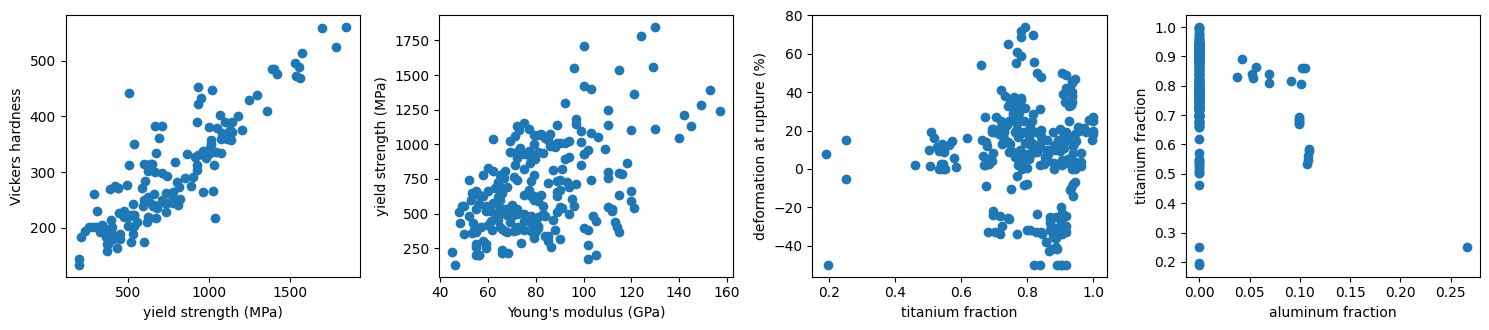

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.4))

axes[0].scatter(hardness['YS_MPa'], hardness['HV'])
axes[0].set_xlabel('yield strength (MPa)')
axes[0].set_ylabel('Vickers hardness')

axes[1].scatter(stiffness['YM_GPa'], stiffness['YS_MPa'])
axes[1].set_xlabel("Young's modulus (GPa)")
axes[1].set_ylabel('yield strength (MPa)')

axes[2].scatter(ductility['Ti_frac'], ductility['DAR_pct'])
axes[2].set_xlabel('titanium fraction')
axes[2].set_ylabel('deformation at rupture (%)')

axes[3].scatter(composition['Al_frac'], composition['Ti_frac'])
axes[3].set_xlabel('aluminum fraction')
axes[3].set_ylabel('titanium fraction')

fig.tight_layout()

### [Check your understanding]

`DAR_pct` is how far a specimen stretched before it broke.

1. Build a table called `ductile` holding the rows where `YS_MPa` and `DAR_pct` are both reported, using `.dropna` with those two column names.
2. Print how many alloys that leaves.
3. Make a `fig, ax` scatter of `DAR_pct` against `YS_MPa`.
4. Label both axes.
5. Compute the Pearson `r` with `r, p = stats.pearsonr(...)`, then print `r`.
6. Evaluate the sign and magnitude of that `r` - what does it mean for someone choosing an alloy?

# Spurious correlations

A large `r` indicates that two columns move together (though sign can be inverted).

It definitely does not indicate **causation**.

[Tyler Vigen's *Spurious Correlations*](https://www.tylervigen.com/spurious-correlations) collects real pairs of numbers that track each other for no reason at all.

Between 2000 and 2009, per capita mozzarella cheese consumption in the United States and the number of civil engineering doctorates awarded rose together with $r = 0.9586$.

*Remember: a strong correlation is worth investigating further, not an explanation.*

# Summary

* The Pearson `r` measures how close two columns come to a straight line, from -1 to +1.
* `r` is built from the deviations of both columns: the sum of their products, divided by the two sums of squares.
* The sign of `r` is the direction and its distance from zero is the strength; the two are independent.
* A large `r` does not establish that one property causes the other.

Across 190 titanium-alloy records, yield strength and tensile strength have $r = 0.882$, a strong positive correlation.

# Quiz 4 warm-up

In Q1 you will:
- read printed output (from statistical calculations),
- say what each number means,
- and caption one of them (indicate its physical interpretation).

In Q2 you will:
- read a line of code and write one sentence on what it does
- Then evaluate a plotting code (whether it's a good choice for the data).

## Further reading

- Salvador, C. A. F. et al. "A compilation of experimental data on the mechanical properties and microstructural features of Ti-alloys." *Scientific Data* 9, 188 (2022). https://doi.org/10.1038/s41597-022-01283-9
- [SciPy documentation: `scipy.stats.pearsonr`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html)
- [Tyler Vigen, *Spurious Correlations*](https://www.tylervigen.com/spurious-correlations)